In [97]:
%config Completer.use_jedi = False
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import os, sys
import time
sys.path.append(os.path.join(os.getcwd(), '../common'))
from utils import timer, save, load

In [45]:
print(f'tensorflow: {tf.__version__}, pandas: {pd.__version__}, numpy: {np.__version__}')

tensorflow: 2.11.0, pandas: 1.5.2, numpy: 1.23.5


In [46]:
TRADE_MONEY_DIR = os.path.join(os.getcwd(), f'../DataStore/trade_money/')

In [47]:
df_trade_money = pd.DataFrame()
for _file in os.listdir(TRADE_MONEY_DIR):
    df_trade_money_tmp = load(f'{TRADE_MONEY_DIR}/{_file}')
    df_trade_money = pd.concat([df_trade_money, df_trade_money_tmp])

In [48]:
df_trade_money.shape

(2127013, 29)

In [99]:
df_trade_money.tail(2)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,buy_sm_vol,buy_sm_amount,sell_sm_vol,sell_sm_amount,buy_md_vol,buy_md_amount,sell_md_vol,sell_md_amount,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
4447,688981.SH,20210826,59.50,60.66,58.87,58.91,59.02,-0.11,-0.1864,395907.14,2370264.143,63679.0,38052.93,66281.0,39706.62,135332.0,80978.38,134834.0,80731.05,143940.0,86235.3,139464.0,83465.13,52967.0,31766.34,55339.0,33130.16,-4487.0,-2411.55
4448,689009.SH,20210826,87.76,87.90,81.18,85.10,86.08,-0.98,-1.1385,46419.20,391849.752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
df_trade_money.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2127013 entries, 0 to 4448
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   ts_code          object 
 1   trade_date       object 
 2   open             float64
 3   high             float64
 4   low              float64
 5   close            float64
 6   pre_close        float64
 7   change           float64
 8   pct_chg          float64
 9   vol              float64
 10  amount           float64
 11  buy_sm_vol       float64
 12  buy_sm_amount    float64
 13  sell_sm_vol      float64
 14  sell_sm_amount   float64
 15  buy_md_vol       float64
 16  buy_md_amount    float64
 17  sell_md_vol      float64
 18  sell_md_amount   float64
 19  buy_lg_vol       float64
 20  buy_lg_amount    float64
 21  sell_lg_vol      float64
 22  sell_lg_amount   float64
 23  buy_elg_vol      float64
 24  buy_elg_amount   float64
 25  sell_elg_vol     float64
 26  sell_elg_amount  float64
 27  net_mf_vol     

In [86]:
data_ =  df_trade_money[df_trade_money.ts_code == "002714.SZ"]

In [87]:
data = data_.sort_values("trade_date", ascending = True)
data.head(2)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
179,002714.SZ,20210104,80.50,84.81,79.99,84.81,77.10,7.71,10.0000,391494.48,...,94995.0,78676.92,112821.0,93905.73,191228.0,160252.10,107036.0,89346.77,33412.0,27587.81
1914,002714.SZ,20210105,88.39,93.29,88.00,93.29,84.81,8.48,9.9988,835537.97,...,226681.0,207763.47,227587.0,208692.11,274579.0,252064.53,283831.0,259971.66,129972.0,121041.60


In [91]:
data[data.trade_date>='20210601'].head(10)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
1156,002714.SZ,20210601,90.08,90.49,86.00,89.99,89.08,0.91,1.0216,348055.02,...,101463.0,89641.83,106300.0,93739.13,72169.0,63584.49,86777.0,76145.83,-1141.0,-1086.52
1156,002714.SZ,20210602,89.98,94.77,89.13,93.11,89.99,3.12,3.4671,311826.97,...,94696.0,87646.42,93745.0,86772.48,47471.0,43868.86,40780.0,37729.44,3195.0,2892.18
1156,002714.SZ,20210603,66.00,69.70,64.57,66.25,65.46,0.79,1.2068,400188.68,...,119321.0,80408.89,130529.0,87990.97,70905.0,47940.33,63787.0,42956.08,-20416.0,-13712.98
1156,002714.SZ,20210604,66.04,68.88,64.38,67.80,66.25,1.55,2.3396,286129.25,...,92180.0,62106.54,80728.0,54431.06,53195.0,36026.08,44216.0,29872.95,3814.0,2722.45
1153,002714.SZ,20210607,66.60,66.65,63.63,64.40,67.80,-3.40,-5.0147,336146.02,...,85872.0,55570.87,97612.0,63098.61,47483.0,30691.52,100354.0,64881.63,-31824.0,-20665.35
1155,002714.SZ,20210608,64.82,65.65,63.78,64.80,64.40,0.40,0.6211,171025.94,...,45277.0,29383.24,47648.0,30906.78,31218.0,20255.90,30540.0,19813.83,19450.0,12684.99
1154,002714.SZ,20210609,64.55,65.85,63.60,65.00,64.80,0.20,0.3086,187694.75,...,54435.0,35297.89,53160.0,34409.10,35379.0,23016.34,33296.0,21609.24,18136.0,11915.76
1155,002714.SZ,20210610,64.60,64.91,63.63,63.91,65.00,-1.09,-1.6769,182390.60,...,44415.0,28492.00,59217.0,37970.68,25682.0,16455.34,40369.0,25854.74,-23519.0,-15029.25
1159,002714.SZ,20210611,63.95,64.25,62.80,62.80,63.91,-1.11,-1.7368,185542.63,...,51850.0,32852.33,61598.0,39042.73,23920.0,15183.40,44233.0,28020.45,-20770.0,-13074.45
1155,002714.SZ,20210615,62.32,62.33,60.50,61.80,62.80,-1.00,-1.5924,249644.96,...,61968.0,38092.42,80696.0,49565.43,32496.0,19959.28,69799.0,42853.98,-693.0,-372.16


In [100]:
data.tail(3)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,buy_sm_vol,buy_sm_amount,sell_sm_vol,sell_sm_amount,buy_md_vol,buy_md_amount,sell_md_vol,sell_md_amount,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
1195,002714.SZ,20221129,46.09,46.96,46.09,46.95,46.20,0.75,1.6234,254766.86,1191097.027,58380.0,27287.14,67137.0,31398.07,88128.0,41203.00,76792.0,35904.07,69895.0,32668.75,80838.0,37790.84,38364.0,17950.81,30000.0,14016.73,25477.0,11935.63
1195,002714.SZ,20221130,47.05,48.78,47.03,48.07,46.95,1.12,2.3855,428043.26,2058240.652,87885.0,42222.31,104216.0,50081.55,117787.0,56600.91,143053.0,68774.68,124880.0,60026.39,133515.0,64228.30,97491.0,46974.45,47259.0,22739.54,48052.0,23150.65
1194,002714.SZ,20221201,48.59,48.70,47.83,48.08,48.07,0.01,0.0208,297485.59,1434657.901,74495.0,35902.11,62053.0,29933.81,97241.0,46888.49,99007.0,47747.19,88821.0,42843.04,91028.0,43896.42,36929.0,17832.15,45398.0,21888.38,-37725.0,-18151.04


In [101]:
18151.04 / 37725.0

0.4811408880053015

In [102]:
1434657.901 / 297485.59

4.82261309194842

In [ ]:
data.pct_chg.mean()

<AxesSubplot: xlabel='trade_date'>

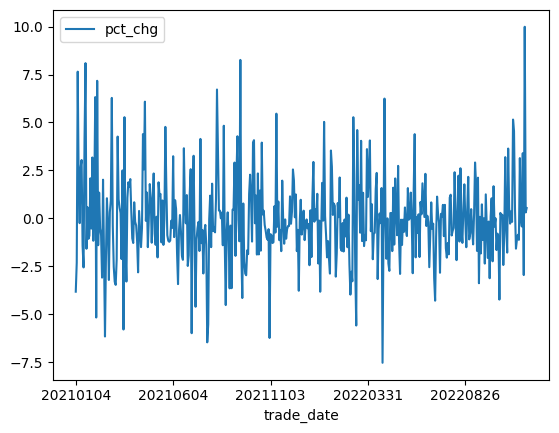

In [84]:
data.plot('trade_date', 'pct_chg')

In [64]:
MIN_DAYS = 14
LAST_DAYS = 7
LAG_COLS = ['open', 'high', 'low', 'close', 'pre_close',
        'vol', 'amount', 'buy_sm_vol', 'buy_sm_amount',
       'sell_sm_vol', 'sell_sm_amount', 'buy_md_vol', 'buy_md_amount',
       'sell_md_vol', 'sell_md_amount', 'buy_lg_vol', 'buy_lg_amount',
       'sell_lg_vol', 'sell_lg_amount', 'buy_elg_vol', 'buy_elg_amount',
       'sell_elg_vol', 'sell_elg_amount', 'net_mf_vol', 'net_mf_amount']
Y = 'close'

def stat_lags(data_, cols):
    if len(data_) <= MIN_DAYS:
        return
    data = data_.sort_values("trade_date", ascending = True)[['ts_code', 'trade_date'] + cols]
    for _col in cols:
        for lag in range(1, LAST_DAYS + 1):
            data[f'{_col}_{lag}'] = data[_col].shift(lag)
    return data.dropna()

def process(data, cols, y):
    sum_cols = []
    for _col in cols:
        if _col == y:
            data[f'{y}_p'] = data[y] * 1.0 / data[f'{y}_1'] - 1
        for lag in range(1, LAST_DAYS):
            data[f'{_col}_p_{lag}'] = data[f'{_col}_{lag}'] * 1.0 / data[f'{_col}_{lag+1}'] - 1
            sum_cols.append(f'{_col}_p_{lag}')
    return data[[f'{y}_p'] + sum_cols]

In [65]:
df_trade_money_lag = df_trade_money.groupby('ts_code').\
                        apply(stat_lags, LAG_COLS)

In [66]:
df_trade_money_lag.reset_index(drop=True).head(2)

,ts_code,trade_date,open,high,low,close,pre_close,vol,amount,buy_sm_vol,...,net_mf_vol_5,net_mf_vol_6,net_mf_vol_7,net_mf_amount_1,net_mf_amount_2,net_mf_amount_3,net_mf_amount_4,net_mf_amount_5,net_mf_amount_6,net_mf_amount_7
0,000001.SZ,20210113,21.00,21.01,20.40,20.70,21.0,1049119.73,2161849.708,166945.0,...,536918.0,-329008.0,-312682.0,22913.27,7923.34,-7429.18,10246.80,101604.09,-59121.70,-58000.12
1,000001.SZ,20210114,20.68,20.89,19.95,20.17,20.7,1130155.62,2306404.546,185899.0,...,50635.0,536918.0,-329008.0,-51134.24,22913.27,7923.34,-7429.18,10246.80,101604.09,-59121.70


In [56]:
# save(df_trade_money_final, "./tmp_store/df_trade_money_final.pkl")
# df_trade_money_final = load("./tmp_store/df_trade_money_final.pkl")

In [67]:
df_trade_money_final = process(df_trade_money_lag, LAG_COLS, Y).reset_index()

In [68]:
df_trade_money_final.head(2)

,ts_code,level_1,close_p,open_p_1,open_p_2,open_p_3,open_p_4,open_p_5,open_p_6,high_p_1,...,net_mf_vol_p_3,net_mf_vol_p_4,net_mf_vol_p_5,net_mf_vol_p_6,net_mf_amount_p_1,net_mf_amount_p_2,net_mf_amount_p_3,net_mf_amount_p_4,net_mf_amount_p_5,net_mf_amount_p_6
0,000001.SZ,717,-0.014286,0.019500,0.005025,0.019467,0.079646,-0.017391,-0.036649,0.017442,...,-1.764017,-0.905693,-2.631930,0.052213,1.891870,-2.066516,-1.725024,-0.899150,-2.718558,0.019338
1,000001.SZ,1284,-0.025604,0.029917,0.019500,0.005025,0.019467,0.079646,-0.017391,0.000476,...,-1.978416,-1.764017,-0.905693,-2.631930,-3.231643,1.891870,-2.066516,-1.725024,-0.899150,-2.718558


In [69]:
df_trade_money_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2067159 entries, 0 to 2067158
Columns: 153 entries, ts_code to net_mf_amount_p_6
dtypes: float64(151), int64(1), object(1)
memory usage: 2.4+ GB


In [70]:
df_trade_money_final_v1 = df_trade_money_final.head(100)

In [76]:
any(df_trade_money_final.buy_sm_vol_p_1 == float("inf"))

True

In [77]:
df_trade_money_lag.shape, df_trade_money_final.shape

((2067159, 353), (2067159, 153))

In [78]:
df_trade_money_lag.loc[df_trade_money_final.buy_sm_vol_p_1 == float("inf")].head()

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [71]:
for _col in df_trade_money_final.columns:
    if float("inf") in df_trade_money_final[_col].values:
        print(_col)

buy_sm_vol_p_1
buy_sm_vol_p_2
buy_sm_vol_p_3
buy_sm_vol_p_4
buy_sm_vol_p_5
buy_sm_vol_p_6
buy_sm_amount_p_1
buy_sm_amount_p_2
buy_sm_amount_p_3
buy_sm_amount_p_4
buy_sm_amount_p_5
buy_sm_amount_p_6
sell_sm_vol_p_1
sell_sm_vol_p_2
sell_sm_vol_p_3
sell_sm_vol_p_4
sell_sm_vol_p_5
sell_sm_vol_p_6
sell_sm_amount_p_1
sell_sm_amount_p_2
sell_sm_amount_p_3
sell_sm_amount_p_4
sell_sm_amount_p_5
sell_sm_amount_p_6
buy_md_vol_p_1
buy_md_vol_p_2
buy_md_vol_p_3
buy_md_vol_p_4
buy_md_vol_p_5
buy_md_vol_p_6
buy_md_amount_p_1
buy_md_amount_p_2
buy_md_amount_p_3
buy_md_amount_p_4
buy_md_amount_p_5
buy_md_amount_p_6
sell_md_vol_p_1
sell_md_vol_p_2
sell_md_vol_p_3
sell_md_vol_p_4
sell_md_vol_p_5
sell_md_vol_p_6
sell_md_amount_p_1
sell_md_amount_p_2
sell_md_amount_p_3
sell_md_amount_p_4
sell_md_amount_p_5
sell_md_amount_p_6
buy_lg_vol_p_1
buy_lg_vol_p_2
buy_lg_vol_p_3
buy_lg_vol_p_4
buy_lg_vol_p_5
buy_lg_vol_p_6
buy_lg_amount_p_1
buy_lg_amount_p_2
buy_lg_amount_p_3
buy_lg_amount_p_4
buy_lg_amount_p_5
buy_

In [63]:
df_trade_money_lag.head(1)

,,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,net_mf_vol_p_3,net_mf_vol_p_4,net_mf_vol_p_5,net_mf_vol_p_6,net_mf_amount_p_1,net_mf_amount_p_2,net_mf_amount_p_3,net_mf_amount_p_4,net_mf_amount_p_5,net_mf_amount_p_6
ts_code,,,,,,,,,,,,,,,,,,,,,,
000001.SZ,717,000001.SZ,20210113,21.0,21.01,20.4,20.7,21.0,-0.3,-1.4286,1049119.73,...,-1.764017,-0.905693,-2.63193,0.052213,1.89187,-2.066516,-1.725024,-0.89915,-2.718558,0.019338


In [41]:
df_trade_money_final_v2['change_p_1'].values

array([ 1.69811321e-01, -1.48387097e+00,  7.66666667e-01, -2.56603774e+00,
        1.04819277e+00, -1.21176471e+00, -1.36111111e+00, -2.84615385e+00,
       -1.66666667e-01, -3.30000000e+00, -1.26086957e+00, -6.91666667e+00,
       -1.38028169e+00, -2.03703704e+00,  4.21428571e+00, -1.86986301e+00,
       -2.31496063e+00, -1.20958084e+00, -1.94285714e+00, -1.39393939e+00,
        6.92307692e-01,  2.45454545e+00, -1.63157895e+00, -1.93750000e+00,
        2.26666667e+00, -6.93877551e-01, -1.51111111e+00, -1.30434783e+00,
        9.14285714e+00, -1.09859155e+00,  1.85714286e+00,  5.80000000e+00,
       -1.06617647e+00,  5.44444444e+00,  2.75862069e-01,  1.35135135e-02,
       -4.00000000e-01, -2.93333333e+00, -7.58620690e-01, -4.28571429e-01,
       -5.00000000e-01, -8.66666667e+00, -2.15217391e+00, -3.37735849e+00,
       -1.85714286e+00, -1.29629630e+00,  1.18750000e+00, -1.31428571e+00,
        7.72727273e-01, -1.02564103e-01,  2.57142857e-01, -8.18181818e-01,
       -3.87500000e+00,  

## Train

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    df_trade_money_final_v2.drop(['ts_code', 'level_1', 'close_p'], axis = 1), 
    df_trade_money_final_v2['close_p'], test_size=0.33, random_state=42)

In [32]:
X_train.shape

(67, 162)

In [38]:
for _col in X_train.columns:
    if float("inf") in X_train[_col].values:
        print(_col)

change_p_2
change_p_5
change_p_6
pct_chg_p_2
pct_chg_p_5
pct_chg_p_6


In [39]:
X_train['change_p_2'].values

array([-1.30434783e+00, -8.92857143e-01,  1.04819277e+00,  1.44444444e+00,
       -3.93258427e-01,  2.75862069e-01, -1.86986301e+00,  7.72727273e-01,
        5.44444444e+00, -1.36111111e+00, -7.41666667e+00, -1.51111111e+00,
       -1.94285714e+00, -3.48837209e-01,  2.26666667e+00,  1.81818182e+00,
       -1.38028169e+00, -1.93750000e+00,  7.66666667e-01, -2.31496063e+00,
       -2.93333333e+00, -2.84615385e+00, -1.06060606e+00, -1.21176471e+00,
       -9.90000000e+00,  1.35135135e-02, -1.53658537e+00, -1.22222222e+00,
       -4.75000000e+00,  2.17391304e-01, -2.15217391e+00, -1.02564103e-01,
       -1.02272727e+00, -1.29629630e+00, -1.13333333e+01, -2.37500000e+00,
       -1.95833333e+00, -2.50000000e+01, -5.00000000e-01,  2.25000000e+00,
       -1.31428571e+00, -4.78260870e-01,  1.00000000e+00,  1.61904762e+00,
        5.80000000e+00,  3.00000000e+00,  1.30769231e+00, -6.77419355e-01,
       -1.73333333e+00, -4.00000000e-01,  9.14285714e+00,  1.69811321e-01,
       -8.18181818e-01,  

In [34]:
X_train

,open_p_1,open_p_2,open_p_3,open_p_4,open_p_5,open_p_6,high_p_1,high_p_2,high_p_3,high_p_4,...,net_mf_vol_p_3,net_mf_vol_p_4,net_mf_vol_p_5,net_mf_vol_p_6,net_mf_amount_p_1,net_mf_amount_p_2,net_mf_amount_p_3,net_mf_amount_p_4,net_mf_amount_p_5,net_mf_amount_p_6
28,-0.035714,0.005837,-0.004915,-0.059664,-0.006678,-0.001667,-0.026596,0.012567,-0.017637,-0.047059,...,-0.381352,-0.041207,0.857989,-8.728235,-0.131003,-0.407535,-0.389595,-0.062658,0.777189,-7.961747
93,-0.007116,-0.012810,-0.005343,-0.014182,-0.009233,0.010958,0.009197,-0.013608,-0.011415,-0.007285,...,-0.552116,0.334929,7.656591,-1.106700,-1.950215,-0.091389,-0.560246,0.319889,7.837086,-1.101547
5,0.061792,0.009524,0.015474,-0.015238,0.029917,0.019500,0.002634,0.037813,0.050742,-0.005712,...,-4.203561,-0.593549,-3.277524,1.888457,-1.163423,0.623460,-4.420992,-0.599232,-3.231643,1.891870
66,0.039910,0.057875,0.052421,-0.016208,-0.019268,-0.001443,0.001725,0.056492,0.033427,0.039648,...,1.825912,-0.324200,-1.874855,5.639066,-1.091467,2.651813,1.909587,-0.294658,-1.873970,5.796805
65,0.057875,0.052421,-0.016208,-0.019268,-0.001443,0.003378,0.056492,0.033427,0.039648,-0.016370,...,-0.324200,-1.874855,5.639066,-0.854523,2.651813,1.909587,-0.294658,-1.873970,5.796805,-0.860755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0.003378,-0.036727,-0.009212,0.011650,-0.019196,0.015313,0.002874,-0.029289,-0.009669,-0.000460,...,-0.006556,0.917859,-0.606891,-4.062834,-0.860755,-0.103378,-0.026203,0.897964,-0.607893,-3.980120
71,0.002147,0.014815,-0.038542,0.023585,0.005606,0.039910,0.011087,0.011212,-0.042922,0.024524,...,-25.889620,-1.023619,-3.307554,-1.092412,-0.274701,0.051664,-84.268830,-1.006953,-3.388523,-1.091467
14,0.008330,0.001317,0.021067,0.000448,0.026703,-0.022942,0.061597,0.015531,-0.012356,0.006432,...,-1.901254,-2.730214,-1.806649,-1.608353,-10.739431,-0.701568,-1.869689,-2.785964,-1.801154,-1.631242
92,-0.012810,-0.005343,-0.014182,-0.009233,0.010958,0.046729,-0.013608,-0.011415,-0.007285,-0.017886,...,0.334929,7.656591,-1.106700,-0.675520,-0.091389,-0.560246,0.319889,7.837086,-1.101547,-0.665346


In [33]:
import statsmodels.api as sm
model = sm.OLS(y_train.values, X_train.values).fit() # 构建最小二乘模型并拟合
print(model.summary()) # 输出回归结果

MissingDataError: exog contains inf or nans